# LV 几何 AHA 17 分区可视化（v2：稳定双视图 + 自定义背景）

相比 v1 的主要改动：

1. **拆分双视图渲染**  
   v1 使用 `pv.Plotter(shape=(1, 2))` 的多子图模式，配合 scalar bar 时左侧外表面偶尔渲染不完整（`scalar_bar_args.position_x` 是相对整个窗口的归一化坐标，在双子图布局下容易错位）。  
   v2 改为对左右视图**分别独立离屏渲染**，再由 matplotlib 在最外层拼合，稳定性更高。

2. **共享离散 legend**  
   将 17 段的图例统一放到最终图片底部，不再占用任何 3D 视图的空间，也不会遮挡 mesh。

3. **可切换背景**  
   通过 `bg_mode = "white" | "transparent"` 选择白底或透明底（论文 / 幻灯片两用）。

4. **headless 更稳**  
   开头自动尝试 `pv.start_xvfb()`，在无显示服务器的环境（远程服务器 / 容器 / CI）下也能渲染。

5. **节点映射向量化**  
   Abaqus `.inp` 解析中把双层 Python 循环替换为 NumPy 查找表，大 mesh 下显著加速。

数据输入不变：Abaqus 六面体 `.inp` + MATLAB 分区 `.mat`。

## 运行前准备

```bash
pip install pyvista vtk scipy matplotlib h5py
```

Linux 服务器 / 容器若没有显示服务器，额外安装 `xvfb`：

```bash
sudo apt-get install -y xvfb libgl1-mesa-glx
```

In [1]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from scipy.io import loadmat

try:
    import h5py   # 仅用于 MATLAB v7.3 文件回退读取
except Exception:
    h5py = None

import pyvista as pv

# 在 headless 环境（服务器 / 容器 / CI）确保能离屏渲染
# 非 Linux 平台会抛异常，用 try/except 静默吃掉
try:
    pv.start_xvfb()
except Exception:
    pass

# 统一 PyVista 背景
pv.global_theme.background = "white"


C:\Users\r4718\AppData\Local\Temp\ipykernel_21024\1810824003.py:20: PyVistaDeprecationWarning: This function is deprecated and will be removed in future version of PyVista. Use vtk with osmesa instead.
  pv.start_xvfb()


In [2]:
# =========================
# 1) 用户配置：只需修改这里
# =========================
inp_path = "hexheartLVmeshF60S45.inp"
mat_path = "AHALVMeshDivisionPCAReconstructed.mat"

# 输出路径
output_dir = "output_dir"
figure_name = "lv_aha17_pyvista_academic.png"
figure_name_raw = "lv_aha17_pyvista_raw.png"    # 可选：PyVista 原生双视图（调试用）
vtu_name = "lv_aha17_mesh.vtu"
save_vtu = True
save_raw_dual = False    # True 时额外输出一张 PyVista 原生拼接图（用于对比）

# 背景模式："white" 或 "transparent"
bg_mode = "white"

# 图像参数
panel_window_size = (1300, 1200)   # 单个面板的离屏渲染窗口
image_scale = 2                     # PyVista 截图放大倍数
show_edges_left = False             # 外表面一般不显示边线，更简洁
show_edges_right = True             # 裁切图显示边线，便于看清分区边界
parallel_projection = True          # 学术静态图通常更适合平行投影
mpl_dpi = 200                        # matplotlib 合成输出的 DPI


In [3]:
# =========================
# 2) AHA 17 分区名称与颜色
# =========================
REGION_NAMES = {
    1: "Basal inferoseptal",
    2: "Basal anteroseptal",
    3: "Basal anterior",
    4: "Basal anterolateral",
    5: "Basal inferolateral",
    6: "Basal inferior",
    7: "Mid inferoseptal",
    8: "Mid anteroseptal",
    9: "Mid anterior",
    10: "Mid anterolateral",
    11: "Mid inferolateral",
    12: "Mid inferior",
    13: "Apical septal",
    14: "Apical anterior",
    15: "Apical lateral",
    16: "Apical inferior",
    17: "Apical cap",
}

# 17 个高区分度颜色（适合离散类别）
REGION_COLORS = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b",
    "#e377c2", "#7f7f7f", "#bcbd22", "#17becf", "#aec7e8", "#ffbb78",
    "#98df8a", "#ff9896", "#c5b0d5", "#c49c94", "#f7b6d2",
]

AHA_CMAP = ListedColormap(REGION_COLORS, name="aha17")
AHA_ANNOTATIONS = {float(i): str(i) for i in range(1, 18)}


In [4]:
# =========================
# 3) 读取 .mat 和 .inp
# =========================
def _load_mat_fallback_v73(mat_file):
    """读取 MATLAB v7.3 (HDF5) 格式的 .mat 文件。"""
    if h5py is None:
        raise RuntimeError(
            "无法用 scipy.io.loadmat 读取该 .mat 文件，且当前环境没有 h5py。"
        )

    with h5py.File(mat_file, "r") as f:
        if "AHALVMeshDivision" not in f:
            raise KeyError("MAT 文件中没有找到 'AHALVMeshDivision' 结构体。")

        grp = f["AHALVMeshDivision"]

        def _read_array(name):
            arr = np.array(grp[name]).squeeze()
            return arr.reshape(-1)

        node_regions = _read_array("nodeRegions").astype(np.int32)
        el_regions = _read_array("elRegions").astype(np.int32)
        return node_regions, el_regions


def load_regions_from_mat(mat_file):
    """读取 nodeRegions 和 elRegions。"""
    try:
        mat = loadmat(mat_file, squeeze_me=True, struct_as_record=False)
        if "AHALVMeshDivision" not in mat:
            raise KeyError("MAT 文件中没有找到 'AHALVMeshDivision'。")

        s = mat["AHALVMeshDivision"]

        if hasattr(s, "nodeRegions"):
            node_regions = np.asarray(s.nodeRegions).reshape(-1).astype(np.int32)
            el_regions = np.asarray(s.elRegions).reshape(-1).astype(np.int32)
            return node_regions, el_regions

        node_regions = np.asarray(s["nodeRegions"]).reshape(-1).astype(np.int32)
        el_regions = np.asarray(s["elRegions"]).reshape(-1).astype(np.int32)
        return node_regions, el_regions

    except NotImplementedError:
        return _load_mat_fallback_v73(mat_file)


def parse_abaqus_inp(inp_file):
    """
    解析 Abaqus .inp 中的：
    - *Node
    - *Element, type=C3D8 / C3D8H

    返回
    ----
    node_ids : (N,) int
    points   : (N, 3) float
    elem_ids : (M,) int
    conn     : (M, 8) int, 0-based node index
    """
    node_ids = []
    points = []
    elem_ids = []
    elem_conn_node_ids = []

    in_nodes = False
    in_elements = False
    element_is_hex8 = False

    with open(inp_file, "r", encoding="utf-8", errors="ignore") as f:
        for raw in f:
            line = raw.strip()

            if not line or line.startswith("**"):
                continue

            if line.startswith("*"):
                upper = line.upper()
                in_nodes = upper.startswith("*NODE")
                in_elements = upper.startswith("*ELEMENT")
                element_is_hex8 = False
                if in_elements and ("TYPE=C3D8" in upper or "TYPE=C3D8H" in upper):
                    element_is_hex8 = True
                continue

            if in_nodes:
                parts = [p.strip() for p in line.split(",") if p.strip()]
                if len(parts) >= 4:
                    node_ids.append(int(parts[0]))
                    points.append([float(parts[1]), float(parts[2]), float(parts[3])])
            elif in_elements and element_is_hex8:
                parts = [p.strip() for p in line.split(",") if p.strip()]
                if len(parts) < 9:
                    raise ValueError(f"六面体单元连通性读取失败，当前行：{line}")
                elem_ids.append(int(parts[0]))
                elem_conn_node_ids.append([int(x) for x in parts[1:9]])

    node_ids = np.asarray(node_ids, dtype=np.int64)
    points = np.asarray(points, dtype=np.float64)
    elem_ids = np.asarray(elem_ids, dtype=np.int64)
    elem_conn_node_ids = np.asarray(elem_conn_node_ids, dtype=np.int64)

    if node_ids.size == 0:
        raise RuntimeError("没有从 .inp 中解析到节点。")
    if elem_ids.size == 0:
        raise RuntimeError("没有从 .inp 中解析到 C3D8/C3D8H 单元。")

    # 向量化：用长度为 max_id+2 的查找表把 Abaqus 节点 ID 映射成 0-based 索引
    max_id = int(node_ids.max())
    lookup = np.full(max_id + 2, -1, dtype=np.int64)
    lookup[node_ids] = np.arange(node_ids.size, dtype=np.int64)

    conn = lookup[elem_conn_node_ids]
    if (conn < 0).any():
        missing = elem_conn_node_ids[conn < 0][:5]
        raise RuntimeError(f"单元引用了未定义的节点 ID，例如：{missing.tolist()}")

    return node_ids, points, elem_ids, conn


In [5]:
# =========================
# 4) 构造 PyVista 网格
# =========================
def build_unstructured_grid(points, conn, node_regions, el_regions):
    """根据点坐标、六面体连通性和标签，构造 PyVista UnstructuredGrid。"""
    if len(points) != len(node_regions):
        raise ValueError(
            f"节点数不一致：mesh 有 {len(points)} 个节点，"
            f"但 nodeRegions 长度为 {len(node_regions)}。"
        )
    if len(conn) != len(el_regions):
        raise ValueError(
            f"单元数不一致：mesh 有 {len(conn)} 个单元，"
            f"但 elRegions 长度为 {len(el_regions)}。"
        )

    n_cells = conn.shape[0]

    # PyVista / VTK 的 cells 扁平格式：[8, p0, p1, ..., p7, 8, p0, ..., p7, ...]
    cells = np.hstack(
        [np.full((n_cells, 1), 8, dtype=np.int64), conn.astype(np.int64)]
    ).ravel()

    celltypes = np.full(n_cells, pv.CellType.HEXAHEDRON, dtype=np.uint8)

    grid = pv.UnstructuredGrid(cells, celltypes, points)
    grid.cell_data["AHA17"] = el_regions.astype(np.int32)
    grid.point_data["AHA17_nodes"] = node_regions.astype(np.int32)

    return grid


def maybe_save_vtu(grid, out_path):
    """可选：保存为 .vtu，便于后续 ParaView / VTK 工作流复用。"""
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    grid.save(out_path)
    return out_path


In [6]:
# =========================
# 5) 渲染辅助函数
# =========================
def compute_camera(bounds):
    """根据模型 bounds 生成较稳的固定相机。"""
    xmin, xmax, ymin, ymax, zmin, zmax = bounds
    center = np.array(
        [(xmin + xmax) / 2, (ymin + ymax) / 2, (zmin + zmax) / 2],
        dtype=float,
    )

    extents = np.array([xmax - xmin, ymax - ymin, zmax - zmin], dtype=float)
    diag = np.linalg.norm(extents)

    # 斜前上方观察，适合 LV 这种长轴朝 Z 的细长结构
    position = center + np.array([1.35, -1.85, 1.05]) * diag
    viewup = (0.0, 0.0, 1.0)
    return [tuple(position), tuple(center), viewup]


def render_single_panel(
    mesh,
    camera,
    window_size=(1300, 1200),
    show_edges=False,
    transparent=False,
    use_parallel=True,
    zoom=1.15,
    scale=2,
):
    """
    渲染单个面板，返回 (H, W, 3 or 4) 的 numpy 图像。

    每个面板独占一个 Plotter（只有一个 renderer），
    避免多 subplot 模式下外表面视图偶发渲染不全的问题。
    """
    pl = pv.Plotter(off_screen=True, window_size=window_size, border=False)
    pl.set_background("white")   # transparent 模式下，screenshot 会用 alpha 替换

    if use_parallel:
        pl.enable_parallel_projection()

    pl.add_mesh(
        mesh,
        scalars="AHA17",
        preference="cell",
        cmap=AHA_CMAP,
        clim=(0.5, 17.5),
        categories=True,
        annotations=AHA_ANNOTATIONS,
        show_scalar_bar=False,    # legend 放到 matplotlib 底部统一画
        interpolate_before_map=False,
        show_edges=show_edges,
        edge_color="#333333",
        line_width=0.7,
        smooth_shading=False,
        ambient=0.18,
        diffuse=0.82,
        specular=0.05,
        lighting=True,
    )

    pl.camera_position = camera
    pl.camera.zoom(zoom)
    pl.render()

    img = pl.screenshot(
        filename=None,
        transparent_background=transparent,
        scale=scale,
        return_img=True,
    )
    pl.close()
    return img


def _draw_discrete_legend(ax, ncol=9, fontsize=9):
    """在 matplotlib axes 中画 17 段的离散 legend。"""
    handles = [
        mpatches.Patch(
            facecolor=REGION_COLORS[i],
            edgecolor="#333333",
            linewidth=0.6,
            label=f"{i + 1:>2d}  {REGION_NAMES[i + 1]}",
        )
        for i in range(17)
    ]
    ax.axis("off")
    ax.legend(
        handles=handles,
        loc="center",
        ncol=ncol,
        fontsize=fontsize,
        frameon=False,
        handlelength=1.2,
        handleheight=1.1,
        columnspacing=1.2,
        borderaxespad=0,
    )


def render_dual_panel_figure(
    grid,
    screenshot_path,
    window_size=(1300, 1200),
    image_scale=2,
    transparent=False,
    dpi=200,
    legend_ncol=9,
):
    """渲染学术风格双视图 + 底部共享 legend，保存 PNG。"""
    surface = grid.extract_surface()

    # 纵向剖切
    center = np.array(grid.center)
    clipped = grid.clip(normal=(1.0, 0.0, 0.0), origin=center, invert=False)
    clipped_surface = clipped.extract_surface()

    camera = compute_camera(grid.bounds)

    img_left = render_single_panel(
        surface, camera,
        window_size=window_size,
        show_edges=show_edges_left,
        transparent=transparent,
        use_parallel=parallel_projection,
        zoom=1.15,
        scale=image_scale,
    )
    img_right = render_single_panel(
        clipped_surface, camera,
        window_size=window_size,
        show_edges=show_edges_right,
        transparent=transparent,
        use_parallel=parallel_projection,
        zoom=1.15,
        scale=image_scale,
    )

    # matplotlib 合成：左视图 + 右视图 + 底部 legend
    fig_facecolor = "none" if transparent else "white"
    fig = plt.figure(figsize=(15, 8), facecolor=fig_facecolor)
    gs = fig.add_gridspec(
        2, 2,
        height_ratios=[1.0, 0.2],
        hspace=0.04, wspace=0.02,
        left=0.01, right=0.99, top=0.96, bottom=0.02,
    )

    ax_left = fig.add_subplot(gs[0, 0])
    ax_left.imshow(img_left)
    ax_left.set_title("Exterior surface", fontsize=14, pad=6)
    ax_left.axis("off")

    ax_right = fig.add_subplot(gs[0, 1])
    ax_right.imshow(img_right)
    ax_right.set_title("Cutaway view", fontsize=14, pad=6)
    ax_right.axis("off")

    ax_legend = fig.add_subplot(gs[1, :])
    _draw_discrete_legend(ax_legend, ncol=legend_ncol, fontsize=9)

    screenshot_path = Path(screenshot_path)
    screenshot_path.parent.mkdir(parents=True, exist_ok=True)

    fig.savefig(
        screenshot_path,
        dpi=dpi,
        bbox_inches="tight",
        facecolor=fig_facecolor,
        transparent=transparent,
    )
    plt.show()

    return img_left, img_right


def render_raw_pyvista_dual(
    grid,
    out_path,
    window_size=(2400, 1100),
    image_scale=2,
    transparent=False,
):
    """可选：PyVista 原生 shape=(1,2) 双视图截图，用于对比调试。"""
    surface = grid.extract_surface()
    center = np.array(grid.center)
    clipped = grid.clip(normal=(1.0, 0.0, 0.0), origin=center, invert=False)
    clipped_surface = clipped.extract_surface()

    pl = pv.Plotter(shape=(1, 2), off_screen=True, window_size=window_size, border=False)
    pl.set_background("white")

    camera = compute_camera(grid.bounds)

    panels = [
        (surface, "Exterior surface", show_edges_left),
        (clipped_surface, "Cutaway view", show_edges_right),
    ]
    for col, (mesh, title, show_edges) in enumerate(panels):
        pl.subplot(0, col)
        if parallel_projection:
            pl.enable_parallel_projection()
        pl.add_mesh(
            mesh,
            scalars="AHA17",
            preference="cell",
            cmap=AHA_CMAP,
            clim=(0.5, 17.5),
            categories=True,
            annotations=AHA_ANNOTATIONS,
            show_scalar_bar=False,
            show_edges=show_edges,
            edge_color="#333333",
            line_width=0.7,
            smooth_shading=False,
            ambient=0.18,
            diffuse=0.82,
            specular=0.05,
        )
        pl.add_text(title, position="upper_left", font_size=14, color="black")
        pl.camera_position = camera
        pl.camera.zoom(1.1)
        pl.render()

    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    pl.screenshot(
        filename=str(out_path),
        scale=image_scale,
        transparent_background=transparent,
    )
    pl.close()
    return out_path


In [7]:
# =========================
# 6) 读取数据并构造网格
# =========================
inp_path = Path(inp_path)
mat_path = Path(mat_path)
output_dir = Path(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)

figure_path = output_dir / figure_name
figure_path_raw = output_dir / figure_name_raw
vtu_path = output_dir / vtu_name

node_regions, el_regions = load_regions_from_mat(mat_path)
node_ids, points, elem_ids, conn = parse_abaqus_inp(inp_path)

grid = build_unstructured_grid(points, conn, node_regions, el_regions)

print(f"Mesh points : {grid.n_points}")
print(f"Mesh cells  : {grid.n_cells}")
print(f"AHA labels  : {np.unique(grid.cell_data['AHA17'])}")

if save_vtu:
    maybe_save_vtu(grid, vtu_path)
    print(f"Saved VTU   : {vtu_path}")


Mesh points : 31856
Mesh cells  : 28650
AHA labels  : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
Saved VTU   : output_dir\lv_aha17_mesh.vtu


In [8]:
# =========================
# 7) AHA 编号 <-> 名称对照
# =========================
for k in range(1, 18):
    print(f"{k:>2d}  ->  {REGION_NAMES[k]}")


 1  ->  Basal inferoseptal
 2  ->  Basal anteroseptal
 3  ->  Basal anterior
 4  ->  Basal anterolateral
 5  ->  Basal inferolateral
 6  ->  Basal inferior
 7  ->  Mid inferoseptal
 8  ->  Mid anteroseptal
 9  ->  Mid anterior
10  ->  Mid anterolateral
11  ->  Mid inferolateral
12  ->  Mid inferior
13  ->  Apical septal
14  ->  Apical anterior
15  ->  Apical lateral
16  ->  Apical inferior
17  ->  Apical cap


C:\Users\r4718\AppData\Local\Temp\ipykernel_21024\2214132355.py:112: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  surface = grid.extract_surface()
C:\Users\r4718\AppData\Local\Temp\ipykernel_21024\2214132355.py:117: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  clipped_surface = clipped.extract_surface()


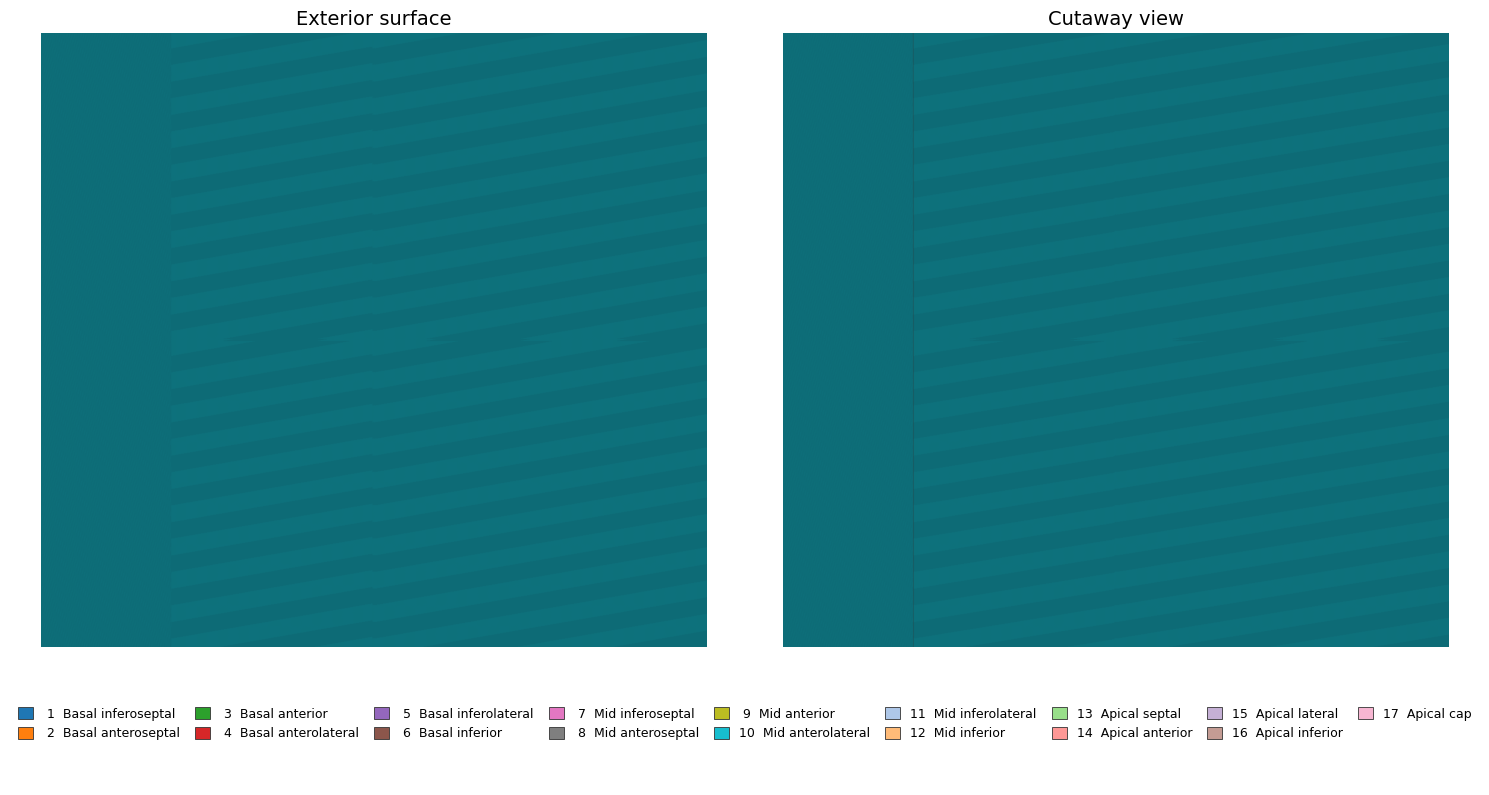

Saved figure: output_dir\lv_aha17_pyvista_academic.png


In [9]:
# =========================
# 8) 生成高分辨率双视图
# =========================
use_transparent = (bg_mode == "transparent")

img_left, img_right = render_dual_panel_figure(
    grid,
    screenshot_path=figure_path,
    window_size=panel_window_size,
    image_scale=image_scale,
    transparent=use_transparent,
    dpi=mpl_dpi,
    legend_ncol=9,
)
print(f"Saved figure: {figure_path}")

if save_raw_dual:
    render_raw_pyvista_dual(
        grid,
        figure_path_raw,
        window_size=(2400, 1100),
        image_scale=image_scale,
        transparent=use_transparent,
    )
    print(f"Saved raw figure: {figure_path_raw}")


## 可选：单独查看裁切后的几何

C:\Users\r4718\AppData\Local\Temp\ipykernel_21024\1582080262.py:6: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  clipped_surface = clipped.extract_surface()


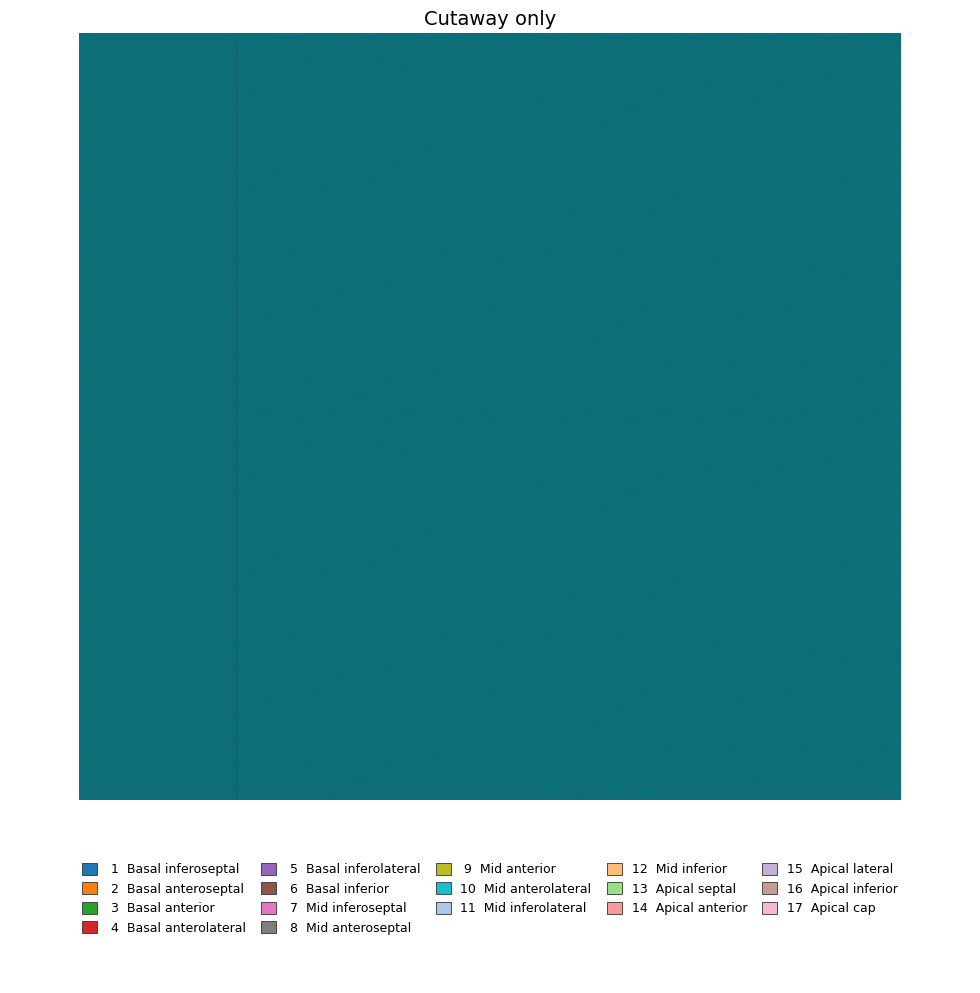

Saved figure: output_dir\lv_aha17_cutaway_only.png


In [10]:
# 单独渲染一张大 cutaway 并配底部 legend
cutaway_path = output_dir / "lv_aha17_cutaway_only.png"

center = np.array(grid.center)
clipped = grid.clip(normal=(1.0, 0.0, 0.0), origin=center, invert=False)
clipped_surface = clipped.extract_surface()

camera = compute_camera(grid.bounds)

img_cut = render_single_panel(
    clipped_surface, camera,
    window_size=(1500, 1400),
    show_edges=True,
    transparent=use_transparent,
    use_parallel=parallel_projection,
    zoom=1.15,
    scale=image_scale,
)

fig_facecolor = "none" if use_transparent else "white"
fig = plt.figure(figsize=(10, 10), facecolor=fig_facecolor)
gs = fig.add_gridspec(
    2, 1,
    height_ratios=[1.0, 0.22],
    hspace=0.03,
    left=0.02, right=0.98, top=0.97, bottom=0.02,
)

ax_cut = fig.add_subplot(gs[0, 0])
ax_cut.imshow(img_cut)
ax_cut.set_title("Cutaway only", fontsize=14, pad=6)
ax_cut.axis("off")

ax_legend = fig.add_subplot(gs[1, 0])
_draw_discrete_legend(ax_legend, ncol=5, fontsize=9)

fig.savefig(
    cutaway_path,
    dpi=mpl_dpi,
    bbox_inches="tight",
    facecolor=fig_facecolor,
    transparent=use_transparent,
)
plt.show()

print(f"Saved figure: {cutaway_path}")


## 使用说明

通常只需要改 **第 1 个配置代码块** 中的：

- `inp_path`、`mat_path`、`output_dir`
- `bg_mode`（`"white"` 或 `"transparent"`）

运行顺序：

1. 依次执行前 8 个代码单元
2. 检查输出目录下的 `.vtu` 与 `.png`
3. 如需单独看剖切视图，再运行最后一个可选单元

## 故障排查

如果最终 PNG 的外表面仍然异常（接近空白或明显破损），按顺序尝试：

1. 把 `save_raw_dual = True`，对比 `lv_aha17_pyvista_raw.png` —— 如果这张也有问题，说明是底层 VTK/OpenGL 渲染问题，不是拼合问题。
2. 在 headless 环境下确认 `pv.start_xvfb()` 实际成功（否则改用 `xvfb-run python -m ipykernel ...` 启动内核）。
3. 把 `panel_window_size` 调小，比如 `(900, 900)`，有些驱动在大 framebuffer 下会黑屏。

## 备注

- 代码按 `elRegions` 做 **cell-wise** 着色，这是分区可视化的正确方式。
- 若要画 35 分区版本，把 `elRegions` 换成 `elRegionsFull`，并相应扩展 `REGION_NAMES` / `REGION_COLORS` 到 35 项即可。